In [1]:
import scanpy as sc

adata = sc.read_h5ad(r"C:\Users\USER\Desktop\資訊所實習\計畫\challenge_nasal_cellxgene_230223.h5ad")

In [2]:
print(adata)

print(adata.obs.columns)
print(adata.var.columns)
print(adata.obsm.keys())
print(adata.uns.keys())

AnnData object with n_obs × n_vars = 234182 × 33559
    obs: 'patient_id', 'time_point', 'covid_status', 'sex', 'cell_state', 'cell_type', 'cell_compartment', 'cell_state_woIFN', 'sequencing_library', 'Institute', 'ObjectCreateDate'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable'
    obsm: 'X_umap_rna_30pcs_6000hvgs'
Index(['patient_id', 'time_point', 'covid_status', 'sex', 'cell_state',
       'cell_type', 'cell_compartment', 'cell_state_woIFN',
       'sequencing_library', 'Institute', 'ObjectCreateDate'],
      dtype='object')
Index(['vst.mean', 'vst.variance', 'vst.variance.expected',
       'vst.variance.standardized', 'vst.variable'],
      dtype='object')
KeysView(AxisArrays with keys: X_umap_rna_30pcs_6000hvgs)
odict_keys([])


In [3]:
adata.obs.head()

,patient_id,time_point,covid_status,sex,cell_state,cell_type,cell_compartment,cell_state_woIFN,sequencing_library,Institute,ObjectCreateDate
COV19_CH11283345_AAACCTGAGCGTGTCC,participant_7,D-1,Transient infection,,Ciliated,Ciliated,Ciliated,Ciliated,COV19_CH11283345,Wellcome Sanger Institute,2023-02-23
COV19_CH11283345_AAACCTGAGTGGGATC,participant_7,D-1,Transient infection,,Ciliated,Ciliated,Ciliated,Ciliated,COV19_CH11283345,Wellcome Sanger Institute,2023-02-23
COV19_CH11283345_AAACCTGTCCTTTCGG,participant_7,D-1,Transient infection,,Secretory,Secretory,Secretory,Secretory,COV19_CH11283345,Wellcome Sanger Institute,2023-02-23
COV19_CH11283345_AAACGGGCACATAACC,participant_7,D-1,Transient infection,,Ciliated,Ciliated,Ciliated,Ciliated,COV19_CH11283345,Wellcome Sanger Institute,2023-02-23
COV19_CH11283345_AAACGGGGTCCATCCT,participant_7,D-1,Transient infection,,Ciliated APR / MHCII+,Ciliated,Ciliated,Ciliated APR / MHCII+,COV19_CH11283345,Wellcome Sanger Institute,2023-02-23


In [6]:
print(adata.obs["cell_type"].value_counts())

cell_type
Ciliated         166318
T CD8             25153
Goblet            10586
Secretory          6442
Basal              5219
Macrophage         3948
T CD4              2971
Ionocyte           2586
Club               1890
Deutorosomal       1307
NK                 1082
T MAI               962
Monocyte            868
cDC2                851
Langerhans          707
cDC Activated       590
B                   466
pDC                 443
T G/D               346
T Reg               302
Hillock             280
Squamous            279
Ductal              275
cDC1                118
AS-DC                95
Mast                 64
Melanocyte           34
Name: count, dtype: int64


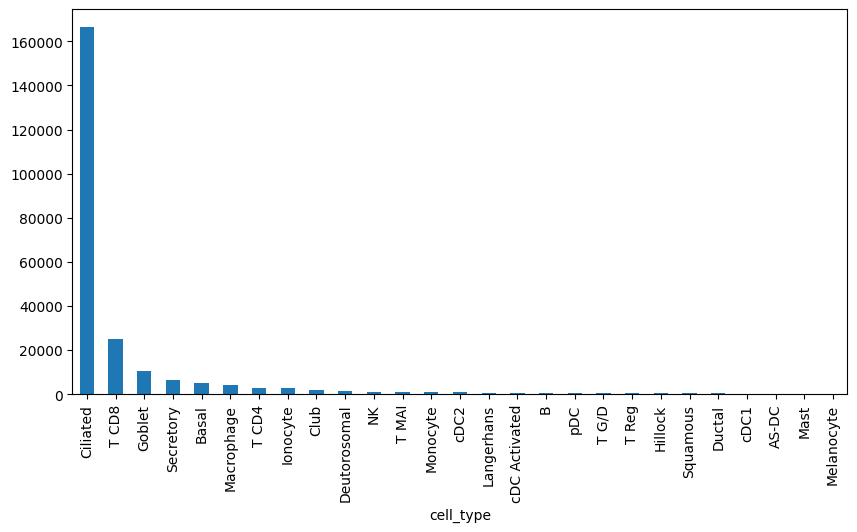

In [5]:
import matplotlib.pyplot as plt

adata.obs["cell_type"].value_counts().plot(
    kind="bar",
    figsize=(10,5)
)

plt.xticks(rotation=90)
plt.show()

In [7]:
print(adata.obs["cell_state"].value_counts())

cell_state
Ciliated                 111572
Ciliated APR / MHCII+     34458
T CD8 Resident Memory     20467
Ciliated IFN stim         19347
Goblet                     7112
                          ...  
B IgD                        12
NK Cycling                   12
B IFN stim IgG               10
B IFN stim IgA                8
B IFN stim IgD                1
Name: count, Length: 76, dtype: int64


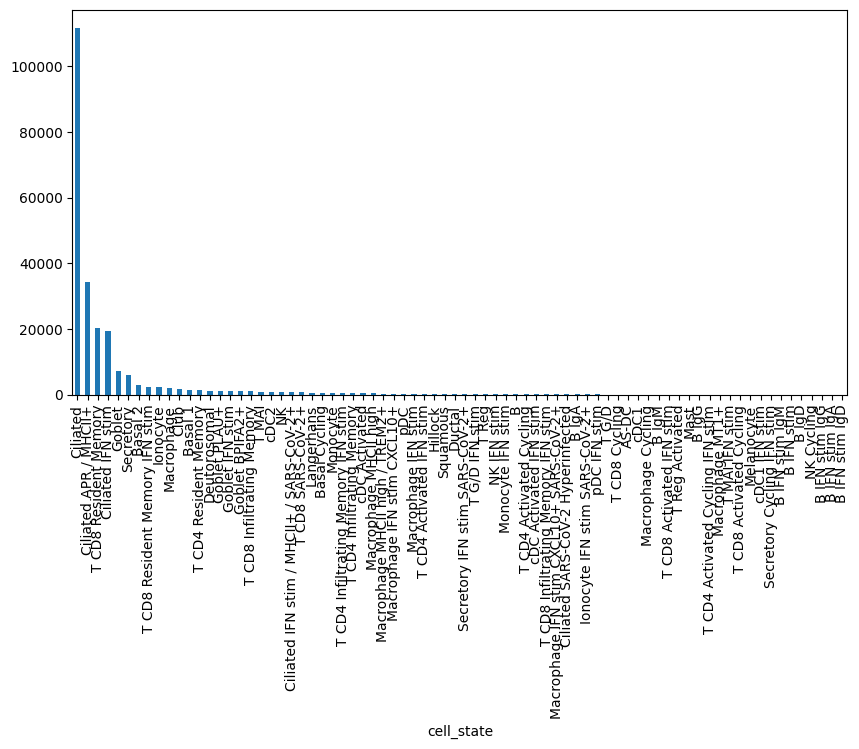

In [22]:
adata.obs["cell_state"].value_counts().plot(
    kind="bar",
    figsize=(10,5)
)

plt.xticks(rotation=90)
plt.show()

In [30]:
import numpy as np

# 每個 cell type 保留數量
n_per_type = 100

selected_cells = (
    adata.obs
    .groupby("cell_type", group_keys=False)
    .apply(
        lambda x: x.sample(
            n=min(len(x), n_per_type),
            random_state=123
        )
    )
    .index
)

adata_sub = adata[selected_cells].copy()

print(adata_sub)

C:\Users\USER\AppData\Local\Temp\ipykernel_29888\3617280068.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("cell_type", group_keys=False)
C:\Users\USER\AppData\Local\Temp\ipykernel_29888\3617280068.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


AnnData object with n_obs × n_vars = 2593 × 33559
    obs: 'patient_id', 'time_point', 'covid_status', 'sex', 'cell_state', 'cell_type', 'cell_compartment', 'cell_state_woIFN', 'sequencing_library', 'Institute', 'ObjectCreateDate'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable'
    obsm: 'X_umap_rna_30pcs_6000hvgs'


In [31]:
adata_hvg = adata_sub[
    :,
    adata_sub.var["vst.variable"]
].copy()

In [32]:
print(adata_hvg)

AnnData object with n_obs × n_vars = 2593 × 8000
    obs: 'patient_id', 'time_point', 'covid_status', 'sex', 'cell_state', 'cell_type', 'cell_compartment', 'cell_state_woIFN', 'sequencing_library', 'Institute', 'ObjectCreateDate'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable'
    obsm: 'X_umap_rna_30pcs_6000hvgs'


In [33]:
import pandas as pd

expr_df = pd.DataFrame(
    adata_hvg.X.toarray(),
    index=adata_hvg.obs_names,
    columns=adata_hvg.var_names
)

In [35]:
cell_type_df = adata_hvg.obs[["cell_type"]]

final_df = pd.concat(
    [
        cell_type_df,
        expr_df
    ],
    axis=1
)

print(final_df.head())

                                  cell_type  AL645608.5  SAMD11  AL645608.8  \
COV19_CH11931834_CGATGTAGTGACTCAT     AS-DC         0.0     0.0         0.0   
COV19_CH11931816_GTACGTACAAGCCTAT     AS-DC         0.0     0.0         0.0   
COV19_CH11283371_GCATACAGTAAACGCG     AS-DC         0.0     0.0         0.0   
COV19_CH11283391_GTGCGGTGTTAAGGGC     AS-DC         0.0     0.0         0.0   
COV19_CH11931841_GTCGTAAGTAGAAGGA     AS-DC         0.0     0.0         0.0   

                                       HES4     ISG15  TNFRSF18  TNFRSF4  \
COV19_CH11931834_CGATGTAGTGACTCAT  0.000000  1.215737       0.0      0.0   
COV19_CH11931816_GTACGTACAAGCCTAT  1.233684  0.473900       0.0      0.0   
COV19_CH11283371_GCATACAGTAAACGCG  3.616444  3.048887       0.0      0.0   
COV19_CH11283391_GTGCGGTGTTAAGGGC  0.000000  1.991147       0.0      0.0   
COV19_CH11931841_GTCGTAAGTAGAAGGA  0.000000  0.000000       0.0      0.0   

                                   VWA1      GNB1  ...  MT-ND6  AC14

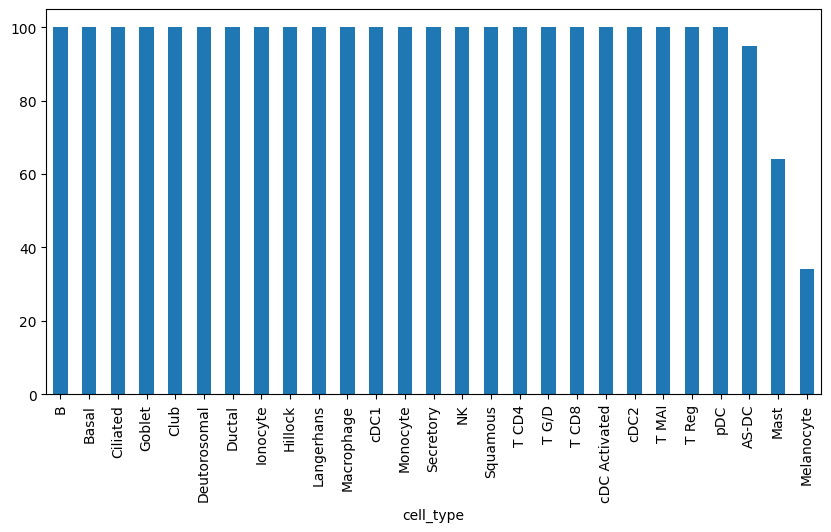

In [36]:
final_df["cell_type"].value_counts().plot(
    kind="bar",
    figsize=(10,5)
)

plt.xticks(rotation=90)
plt.show()

In [37]:
final_df = final_df.reset_index()

final_df = final_df.rename(
    columns={"index": "cell_id"}
)

In [38]:
final_df.to_csv(
    r"C:\Users\USER\Desktop\資訊所實習\計畫\資料探勘\nasal_scRNA_HVG_100cells.csv",
    index=False
)